## Preparing and Training models for **Eyes Open**

### Importing libraries

In [ ]:
%pip install xgboost

import os
import warnings

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.signal import hilbert
from scipy.stats import pearsonr, spearmanr

from xgboost import XGBClassifier

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE, SelectKBest, f_classif, f_regression, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, auc, classification_report, 
    confusion_matrix, f1_score, log_loss, make_scorer, mean_squared_error, 
    r2_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    GridSearchCV, KFold, LeaveOneOut, RandomizedSearchCV, StratifiedKFold, 
    cross_val_predict, cross_val_score, permutation_test_score, train_test_split
)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.utils import resample

warnings.filterwarnings('ignore')

### Merging tables

In [86]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

In [87]:
# Shows the first 5 rows of the table with all columns
display(df_complete.head())

print(f"\nTotal patients with pain scores: {df_complete.shape[0]}")
print(f"Total merged columns: {df_complete.shape[1]}")

,ID,Pain Score (Actual Pain of Brief Pain Inventory),Age,Gender,Etiology of NP*,Time with NP,Medical treatment for NP,Since when have you use the previous medication?,Have you had any medical procedures to control the pain?,Do you go regularly to phsychological or emotional counseling sessions for your pain?,...,Please write your main area of pain,Does your pain radiate to other regions of your body?,"If the answer is yes, please write the direction in which it irradiates as explicitly as possible","Do you suffer from a burning sensation (e.g., stinging nettles) in the marked areas?",Do you have a tingling or prickling sensation in the area of your pain (like crawling ants or electrical tingling)?,"Is light touching (clothing, a blanket) in this area painful?","Do you have sudden pain attacks in the area of your pain, like electric shocks?",Is cold or heat (bath water) in this area occasionally painful?,Do you suffer from a sensation of numbness in the areas that you marked?,"Does slight pressure in this area, e.g., with a finger, trigger pain?"
0,0,7.0,25.0,F,Central Nervous System Disorder (CRPS or Lyme),More than 2 years,"Pregabalin, amitriptyline",More than a year ago,Nerve blocks and infusions*,Yes,...,Soles of feet and palms of hands,Yes,"From the feet to lower back, from the hands to...",Strongly,Strongly,Strongly,Very Strongly,Very Strongly,Strongly,Moderately
1,1,4.0,57.0,F,Diabetes,More than 2 years,Tramadol,More than a month ago,NaN,No,...,Sole of feet,No,NaN,Very Strongly,Strongly,Strongly,Strongly,Strongly,Strongly,Strongly
2,2,3.0,20.0,F,Peripheral neuropathy,More than 2 years,Keterolac,More than a year ago,NaN,No,...,Wrist and hand,Yes,From the wrist to the fingers,Never,Moderately,Never,Moderately,Strongly,Very Strongly,Slightly
3,3,8.0,34.0,F,Spinal cord or nerve root injury,More than 2 years,Tramadol,More than a year ago,Physiotherapy,No,...,Lower back,No,NaN,Strongly,Moderately,Never,Never,Moderately,Never,Very Strongly
4,4,5.0,77.0,M,Spinal cord or nerve root injury,More than 2 years,NaN,NaN,NaN,No,...,"Legs, back, neck and head",Yes,To the limbs,Never,Strongly,Never,Strongly,Never,Strongly,Strongly



Total patients with pain scores: 36
Total merged columns: 35


### Definition of EEG bands and asymmetry pairs

In [88]:
bands = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

asymmetry_pairs = {
    'Fp1': 'Fp2',
    'F3': 'F4',
    'C3': 'C4',
    'P3': 'P4',
    'O1': 'O2',
    'F7': 'F8',
    'T7': 'T8',
    'P7': 'P8'
}

X_features = []
y_labels = []
feature_names = []
eeg_folder = './cleaned' 

### EEG feature extraction loop

In [89]:
def compute_pac_mi(data, sfreq, f_phase, f_amp, n_bins=18):
    # Calculates Phase-Amplitude Coupling (PAC) using the Modulation Index (MI)
    data_2d = np.array([data], dtype=np.float64)
    
    # Filter the signal for Phase and Amplitude frequencies
    phase_signal = mne.filter.filter_data(data_2d, sfreq, l_freq=f_phase[0], h_freq=f_phase[1], verbose=False)[0]
    amp_signal = mne.filter.filter_data(data_2d, sfreq, l_freq=f_amp[0], h_freq=f_amp[1], verbose=False)[0]
    
    # Extract Phase and Amplitude using the Hilbert Transform
    phase = np.angle(hilbert(phase_signal))
    amp = np.abs(hilbert(amp_signal))
    
    # Binning (Grouping amplitudes based on phase angle)
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    bin_amp_mean = np.zeros(n_bins)
    
    for i in range(n_bins):
        idx = np.where((phase >= bins[i]) & (phase < bins[i+1]))[0]
        if len(idx) > 0:
            bin_amp_mean[i] = np.mean(amp[idx])
            
    # Normalize the amplitudes to create a probability distribution
    sum_amp = np.sum(bin_amp_mean)
    if sum_amp == 0:
        return 0
    p_j = bin_amp_mean / sum_amp
    
    # Calculate the Modulation Index (Shannon Entropy vs Maximum Entropy)
    h_max = np.log(n_bins)
    h = -np.sum(p_j[p_j > 0] * np.log(p_j[p_j > 0]))
    
    mi = (h_max - h) / h_max
    return mi

# Extraction Configurations
pac_pairs = [
    ('Theta', 'Beta'),
    ('Theta', 'Gamma'),
    ('Alpha', 'Beta'),
    ('Alpha', 'Gamma')
]

target_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

X_features = []
y_labels = []
feature_names = []

for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID'])) 
    pain_score = float(row['Actual Pain']) 
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eo_eeg.fif")
    
    if os.path.exists(path):
        try:
            raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
            all_channels = raw.ch_names
            sfreq = raw.info['sfreq']
            raw_data = raw.get_data()
            
            psd = raw.compute_psd(fmin=4, fmax=40, method='welch', verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            patient_features = []
            channel_power = {}
            channel_pac = {}
            temp_names = [] 
            
            # CHANNEL LOOP
            for channel in target_channels:
                if channel in all_channels:
                    i = all_channels.index(channel)
                    channel_signal = raw_data[i, :]
                    
                    # Conventional Power
                    channel_power[channel] = {}
                    for band_name, (fmin, fmax) in bands.items():
                        band_idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                        power = np.sum(psd_data[i, band_idx])
                        channel_power[channel][band_name] = power
                        patient_features.append(power)
                        if not feature_names: temp_names.append(f"Pow_{channel}_{band_name}")
                
                    # PAC Coupling
                    channel_pac[channel] = {}
                    for (f_phase, f_amp) in pac_pairs:
                        mi = compute_pac_mi(channel_signal, sfreq, bands[f_phase], bands[f_amp])
                        pac_name = f"{f_phase}-{f_amp}"
                        channel_pac[channel][pac_name] = mi
                        patient_features.append(mi)
                        if not feature_names: temp_names.append(f"PAC_{channel}_{pac_name}")
                        
                else:
                    # Filling for missing channels
                    for band_name in bands.keys():
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Pow_{channel}_{band_name}")
                    for (f_phase, f_amp) in pac_pairs:
                        patient_features.append(np.nan)
                        pac_name = f"{f_phase}-{f_amp}"
                        if not feature_names: temp_names.append(f"PAC_{channel}_{pac_name}")

            # HEMISPHERIC ASYMMETRY LOOP
            for left_channel, right_channel in asymmetry_pairs.items():
                if left_channel in channel_power and right_channel in channel_power:
                    # Power Asymmetry
                    for band_name in bands.keys():
                        p_left = channel_power[left_channel][band_name]
                        p_right = channel_power[right_channel][band_name]
                        asymmetry = (p_right - p_left) / (p_right + p_left) if (p_right + p_left) != 0 else 0
                        patient_features.append(asymmetry)
                        if not feature_names: temp_names.append(f"Asym_Pow_{left_channel}-{right_channel}_{band_name}")
                    
                    # PAC Asymmetry
                    for (f_phase, f_amp) in pac_pairs:
                        pac_name = f"{f_phase}-{f_amp}"
                        p_left_pac = channel_pac[left_channel][pac_name]
                        p_right_pac = channel_pac[right_channel][pac_name]
                        asymmetry_pac = (p_right_pac - p_left_pac) / (p_right_pac + p_left_pac) if (p_right_pac + p_left_pac) != 0 else 0
                        patient_features.append(asymmetry_pac)
                        if not feature_names: temp_names.append(f"Asym_PAC_{left_channel}-{right_channel}_{pac_name}")
                else:
                    # Filling for missing asymmetry pairs
                    for band_name in bands.keys():
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Asym_Pow_{left_channel}-{right_channel}_{band_name}")
                    for (f_phase, f_amp) in pac_pairs:
                        patient_features.append(np.nan)
                        if not feature_names: temp_names.append(f"Asym_PAC_{left_channel}-{right_channel}_{f_phase}-{f_amp}")
            
            if not feature_names: feature_names = temp_names
            X_features.append(patient_features)
            y_labels.append(pain_score)
            print(f"[OK] Patient {patient_id}'s EEG finished.")
            
        except Exception as e:
            print(f"[ERROR] Failed on patient {patient_id}: {e}")
  
X = np.array(X_features)
y = np.array(y_labels)

# Final Cleaning
valid_columns = ~np.isnan(X).all(axis=0) 
X = X[:, valid_columns]
feature_names = np.array(feature_names)[valid_columns].tolist()

print("\nEXTRACTION COMPLETED")
print(f"Final Matrix Shape: {X.shape}")
print(f"Total valid Biomarkers: {len(feature_names)}")

[OK] Patient 0's EEG finished.
[OK] Patient 1's EEG finished.
[OK] Patient 2's EEG finished.
[OK] Patient 3's EEG finished.
[OK] Patient 4's EEG finished.
[OK] Patient 5's EEG finished.
[OK] Patient 6's EEG finished.
[OK] Patient 7's EEG finished.
[OK] Patient 8's EEG finished.
[OK] Patient 9's EEG finished.
[OK] Patient 10's EEG finished.
[OK] Patient 11's EEG finished.
[OK] Patient 13's EEG finished.
[OK] Patient 14's EEG finished.
[OK] Patient 15's EEG finished.
[OK] Patient 16's EEG finished.
[OK] Patient 18's EEG finished.
[OK] Patient 19's EEG finished.
[OK] Patient 20's EEG finished.
[OK] Patient 21's EEG finished.
[OK] Patient 22's EEG finished.
[OK] Patient 23's EEG finished.
[OK] Patient 24's EEG finished.
[OK] Patient 25's EEG finished.
[OK] Patient 26's EEG finished.
[OK] Patient 27's EEG finished.
[OK] Patient 30's EEG finished.
[OK] Patient 31's EEG finished.
[OK] Patient 33's EEG finished.
[OK] Patient 35's EEG finished.
[OK] Patient 37's EEG finished.
[OK] Patient 38's 

### Machine Learning (feature selection and models)

#### Gaussian Naive Bayes

Evaluating Gaussian Naive Bayes - mutual_info, balanced priors, LOO + RandomizedSearchCV

Severe Pain (>=6): 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV with Gaussian Naive Bayes

CLASSIFICATION PERFORMANCE (LOO NESTED CV + GAUSSIAN NB)
LOO Accuracy: 52.8%
LOO AUC-ROC: 0.515

Best hyperparameters: k=7, var_smoothing=7.28e-09

-------------------------------------------------------
TOP 7 BIOMARKERS (GAUSSIAN NB + mutual_info SelectKBest):
  1. PAC_Fz_Alpha-Gamma  (MI score weight: 17.5%)
  2. Pow_F3_Alpha  (MI score weight: 16.0%)
  3. Asym_Pow_F7-F8_Gamma  (MI score weight: 15.1%)
  4. Asym_Pow_P3-P4_Alpha  (MI score weight: 13.4%)
  5. PAC_P3_Alpha-Beta  (MI score weight: 13.3%)
  6. Asym_Pow_P3-P4_Theta  (MI score weight: 12.4%)
  7. Asym_Pow_F7-F8_Beta  (MI score weight: 12.2%)


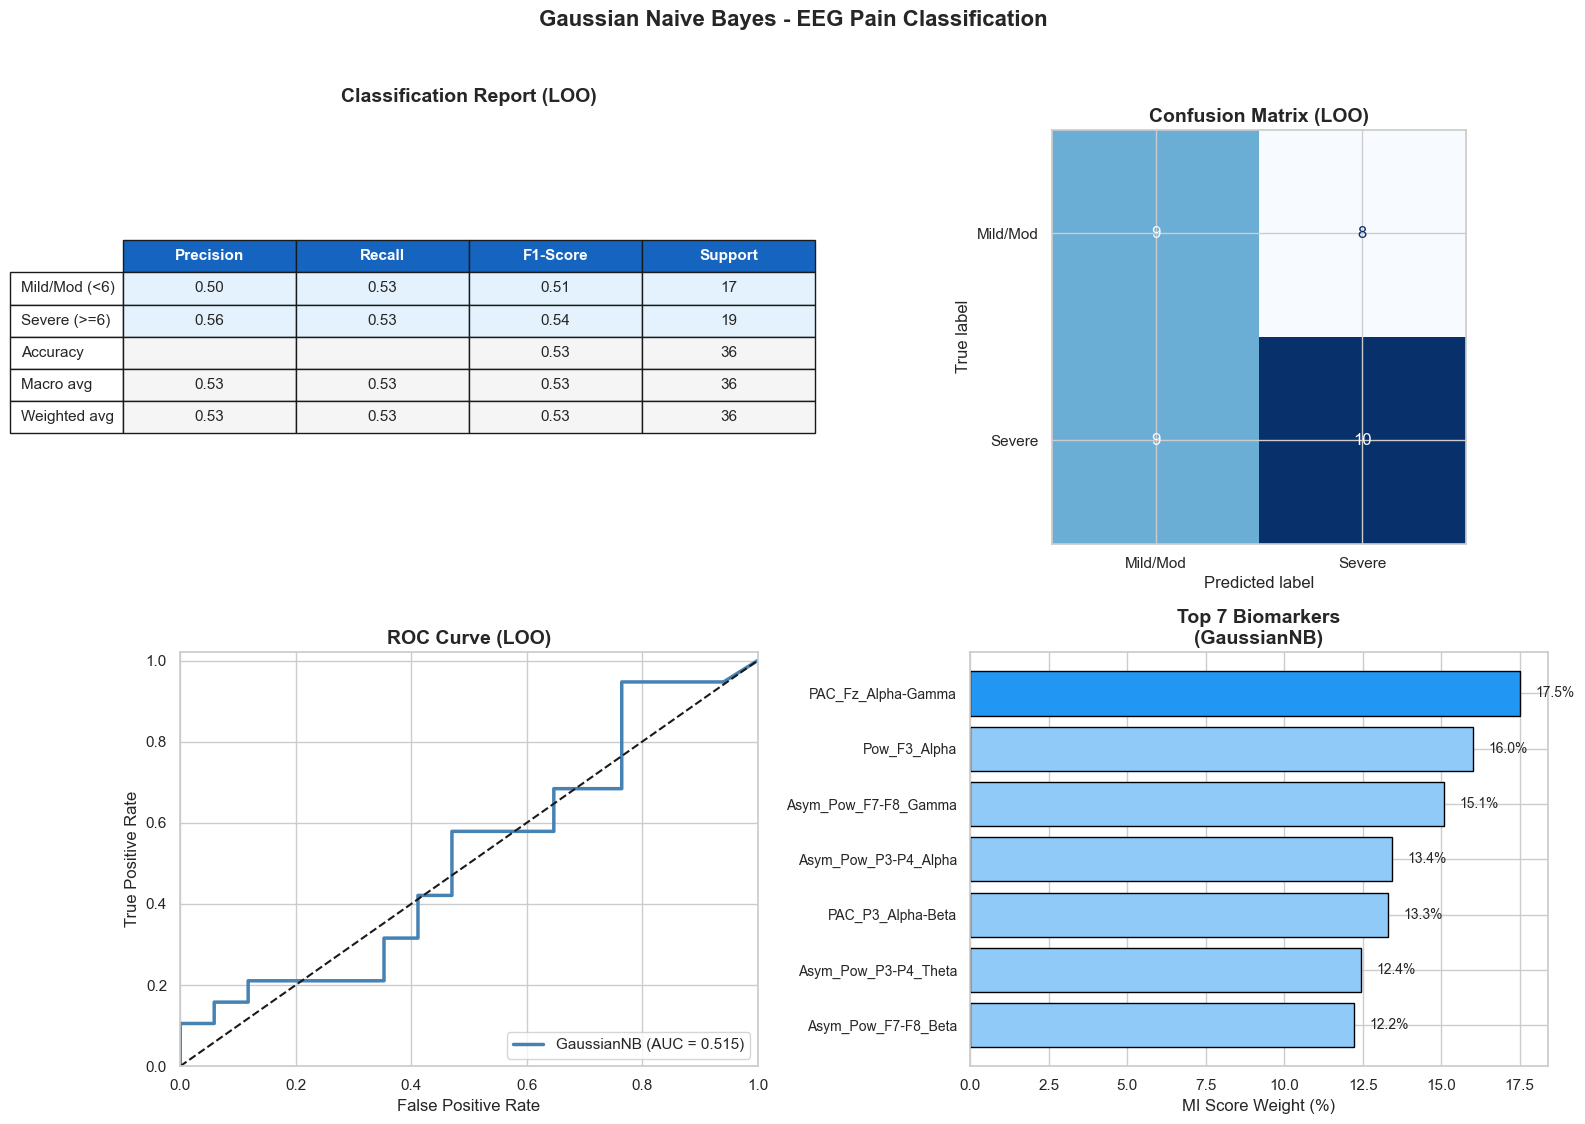


Figure saved as images\gnb_full_results.png


In [94]:
if X.shape[0] > 0:
    print('=' * 60)
    print("Evaluating Gaussian Naive Bayes - mutual_info, balanced priors, LOO + RandomizedSearchCV\n")
    print('=' * 60)

    # M1/M2 Filtering
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    n_sev = int(sum(y_class == 1))
    n_mild = int(sum(y_class == 0))
    total = len(y_class)
    print(f"Severe Pain (>=6): {n_sev}")
    print(f"Mild/Mod Pain (<6): {n_mild}\n")

    # Balanced priors (equivalent to class_weight='balanced' in RF)
    balanced_priors = [0.5, 0.5]

    num_k = 5

    # Pipeline
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=num_k)),
        ('gnb', GaussianNB(priors=balanced_priors))
    ])

    # Hyperparameters
    param_dist = {
        'gnb__var_smoothing': np.logspace(-10, -1, num=30),
        'selector__k': [3, 5, 7, 10],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=20, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    # LOO Nested CV
    print("Running LOO Nested CV with Gaussian Naive Bayes")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    y_pred_loo = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    y_proba_loo = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='predict_proba')[:, 1]
    auc_loo = roc_auc_score(y_class, y_proba_loo)

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV + GAUSSIAN NB)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")
    
    # Generate classification report dict for the table
    report = classification_report(y_class, y_pred_loo,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Train on full dataset to reveal biomarkers
    search.fit(X_filtered, y_class)
    best_k = search.best_params_.get('selector__k', num_k)
    best_vs = search.best_params_.get('gnb__var_smoothing')
    print(f"\nBest hyperparameters: k={best_k}, var_smoothing={best_vs:.2e}\n")

    selector = search.best_estimator_.named_steps['selector']
    mask = selector.get_support()
    biomarkers = feature_names_filt[mask]

    # GNB doesn't have feature_importances_ -> uses F-scores from SelectKBest
    scores = selector.scores_[mask]
    scores_pct = scores / scores.sum() * 100
    ranking = np.argsort(scores_pct)[::-1]

    print('-' * 55)
    print(f"TOP {best_k} BIOMARKERS (GAUSSIAN NB + mutual_info SelectKBest):")
    for rank, i in enumerate(ranking, 1):
        print(f"  {rank}. {biomarkers[i]}  (MI score weight: {scores_pct[i]:.1f}%)")

    # VISUALIZATIONS (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#1565c0')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#e3f2fd')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5')

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred_loo)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba_loo)
    ax_roc.plot(fpr, tpr, color='steelblue', lw=2.5,
                label=f'GaussianNB (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    bios_ordered  = biomarkers[ranking]
    scores_ordered = scores_pct[ranking]
    colors = ['#2196F3' if s == scores_ordered.max() else '#90CAF9' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('MI Score Weight (%)', fontsize=12)
    ax_feat.set_title(f'Top {best_k} Biomarkers\n(GaussianNB)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle('Gaussian Naive Bayes - EEG Pain Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'gnb_full_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

else:
    print("No patients processed")

#### Random Forest with Classification

Evaluating RF Classifier — mutual_info, class_weight='balanced', LOO + RandomizedSearchCV
Original features: 144
Features after removing M1/M2: 144

Severe Pain (>=6): 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV

CLASSIFICATION PERFORMANCE (LOO NESTED CV)
LOO Accuracy: 50.0%
LOO AUC-ROC: 0.393

Best hyperparameters: {'rf__n_estimators': 50, 'rf__min_samples_leaf': 2, 'rf__max_depth': None}
-------------------------------------------------------

TOP 5 BIOMARKERS (RF Classifier + mutual_info + balanced)
  - Asym_Pow_F7-F8_Gamma: 30.9% importance
  - PAC_Fz_Alpha-Gamma: 24.7% importance
  - Asym_Pow_P3-P4_Alpha: 18.9% importance
  - Pow_F3_Alpha: 13.8% importance
  - PAC_P3_Alpha-Beta: 11.7% importance


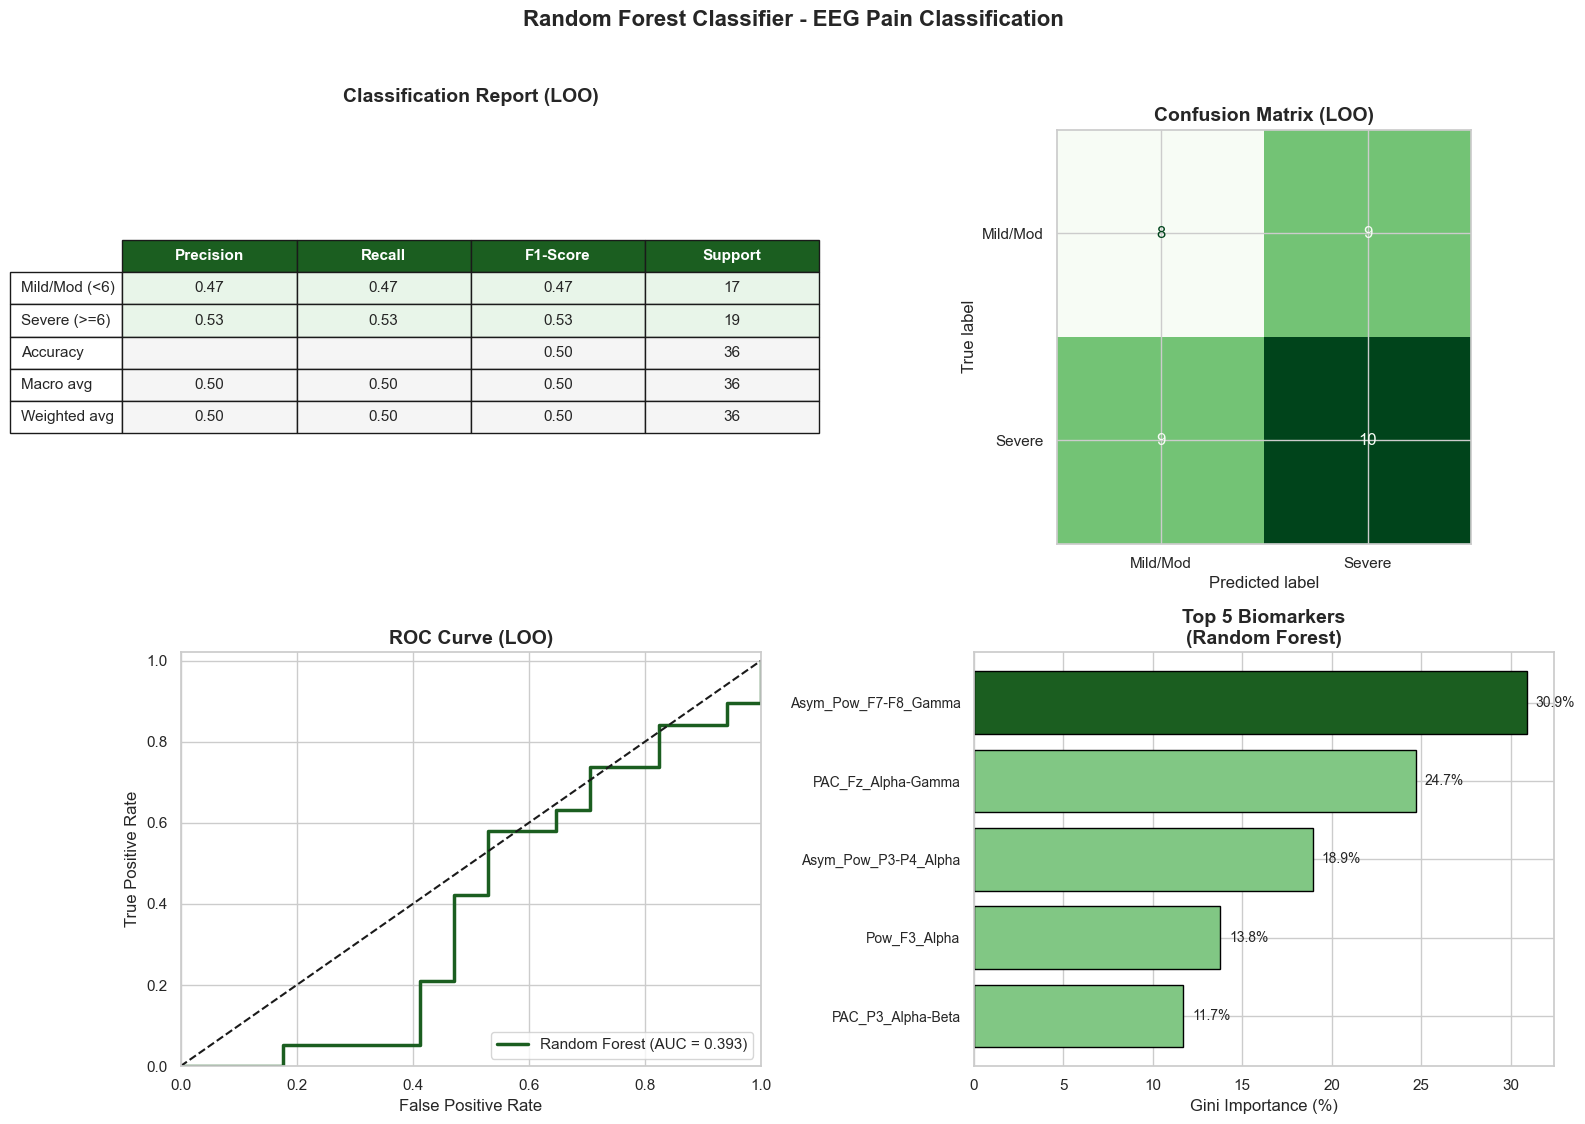


Figure saved as images\rf_full_results.png


In [101]:
if X.shape[0] > 0:
    print('=' * 60)
    print("Evaluating RF Classifier — mutual_info, class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)
    
    # M1/M2 Filtration
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    print(f"Original features: {X.shape[1]}")
    print(f"Features after removing M1/M2: {X_filtered.shape[1]}\n")

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_k = 5

    # Base pipeline
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # mutual_info_classif captures non-linear relationships between features and target
        ('selector', SelectKBest(score_func=mutual_info_classif, k=num_k)),
        # class_weight='balanced' automatically corrects class imbalance
        ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])

    param_dist = {
        'rf__n_estimators': [50, 100, 200, 300],
        'rf__max_depth': [2, 3, 5, None],
        'rf__min_samples_leaf': [1, 2, 4],
    }

    # Inner CV: StratifiedKFold preserves class proportions in each fold
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut() # LOO: each patient becomes the test set once

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=20, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    # LOO outer loop
    print("Running LOO Nested CV")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')

    # AUC-ROC requires cross_val_predict because LOO has only 1 sample per test fold
    y_proba = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='predict_proba')[:, 1]
    auc_loo = roc_auc_score(y_class, y_proba)
    
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    selector = search.best_estimator_.named_steps['selector']
    mask = selector.get_support()
    biomarkers = feature_names_filt[mask]
    importances = search.best_estimator_.named_steps['rf'].feature_importances_
    
    ranking = np.argsort(importances)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARKERS (RF Classifier + mutual_info + balanced)")
    for idx in ranking:
        print(f"  - {biomarkers[idx]}: {importances[idx]*100:.1f}% importance")

    # VISUALIZATIONS
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    # Flatten axes for easier assignment
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#1b5e20')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#e8f5e9')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5')

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Greens')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba)
    ax_roc.plot(fpr, tpr, color='#1b5e20', lw=2.5,
                label=f'Random Forest (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    bios_ordered = biomarkers[ranking]
    imps_ordered = importances[ranking] * 100 # Convert to percentage
    
    colors_rf = ['#1b5e20' if i == imps_ordered.max() else '#81c784' for i in imps_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), imps_ordered[::-1], color=colors_rf[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Gini Importance (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarkers\n(Random Forest)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, imps_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle('Random Forest Classifier - EEG Pain Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'rf_full_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

else:
    print("No patients processed.")

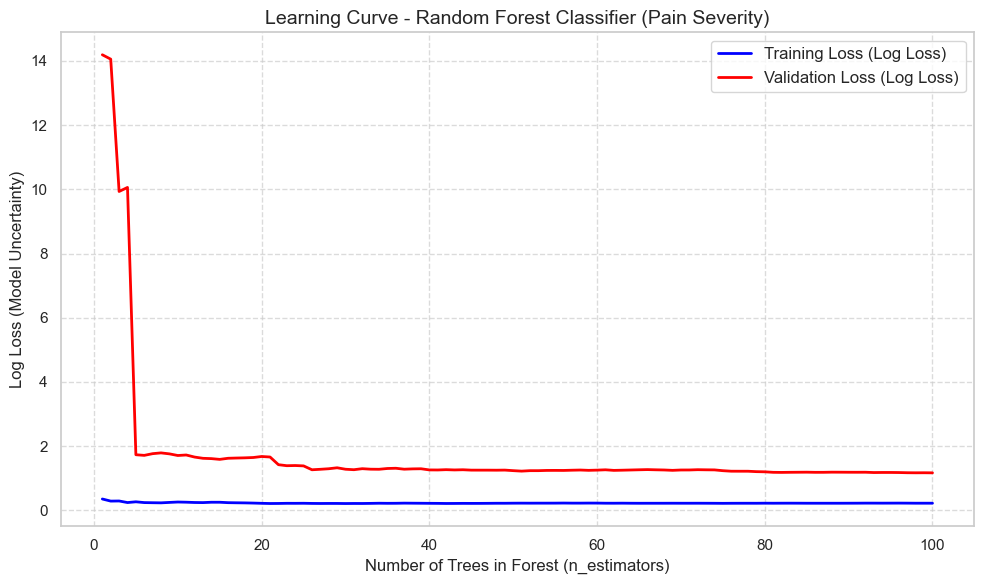


Figure saved as images\rf_learning_curve.png

TOP 5 BIOMARKERS USED IN THIS CURVE:
1. Pow_O2_Alpha
2. Pow_F8_Alpha
3. Pow_Pz_Alpha
4. Asym_Pow_C3-C4_Beta
5. Asym_Pow_C3-C4_Gamma


In [103]:
if X.shape[0] > 0:
    # Transform the target (y) from continuous to binary (0 or 1)
    y_class = np.where(y >= 6, 1, 0)
    
    # Split Train and Validation sets
    # We use stratify=y_class to ensure the same severity proportion in both groups
    X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)
    
    num_features_to_select = 5
    
    # Apply Scaler and Selector manually (replicating the Pipeline)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # In classification, the score function is f_classif, not f_regression
    selector = SelectKBest(score_func=f_classif, k=num_features_to_select)
    X_train_final = selector.fit_transform(X_train_scaled, y_train)
    X_test_final = selector.transform(X_test_scaled)
    
    # Configure Random Forest Classifier with warm_start=True
    rf_class = RandomForestClassifier(
        n_estimators=1, 
        max_depth=3, 
        random_state=42,
        warm_start=True,
        n_jobs=-1
    )
    
    # Lists to store Log Loss for each tree added
    train_loss = []
    val_loss = []
    n_trees_range = range(1, 101) # From 1 to 100 trees
    
    # "Epochs" loop (Adding trees one by one)
    for i in n_trees_range:
        rf_class.set_params(n_estimators=i)
        rf_class.fit(X_train_final, y_train)
        
        # In classification, Log Loss uses predicted PROBABILITIES, not just classes (0 or 1)
        y_train_pred_prob = rf_class.predict_proba(X_train_final)
        y_test_pred_prob = rf_class.predict_proba(X_test_final)
        
        # Calculate Log Loss (lower means the model is more confident and accurate)
        loss_t = log_loss(y_train, y_train_pred_prob)
        loss_v = log_loss(y_test, y_test_pred_prob)
        
        train_loss.append(loss_t)
        val_loss.append(loss_v)

    # Plot the Loss Curve
    plt.figure(figsize=(10, 6))
    plt.plot(n_trees_range, train_loss, label='Training Loss (Log Loss)', color='blue', linewidth=2)
    plt.plot(n_trees_range, val_loss, label='Validation Loss (Log Loss)', color='red', linewidth=2)
    
    plt.title('Learning Curve - Random Forest Classifier (Pain Severity)', fontsize=14)
    plt.xlabel('Number of Trees in Forest (n_estimators)', fontsize=12)
    plt.ylabel('Log Loss (Model Uncertainty)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'rf_learning_curve.png')
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

    # Display the features used in this test
    mask = selector.get_support()
    final_biomarkers = np.array(feature_names)[mask]
    
    print(f"\nTOP {num_features_to_select} BIOMARKERS USED IN THIS CURVE:")
    for i, bio in enumerate(final_biomarkers, 1):
        print(f"{i}. {bio}")

else:
    print("No patients processed.")
    

#### Logistic Regression

Evaluating Logistic Regression + RFE — class_weight='balanced', LOO + RandomizedSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV with Logistic Regression + RFE

CLASSIFICATION PERFORMANCE (LOO NESTED CV + LOGISTIC REGRESSION)
LOO Accuracy: 86.1%
LOO AUC-ROC: 0.935

Best hyperparameters: {'logreg_final__C': 2.0}
-------------------------------------------------------

TOP 5 BIOMARKERS (LOGISTIC REGRESSION + RFE):
  1. Asym_PAC_F7-F8_Alpha-Beta: 27.6% importance
  2. Asym_Pow_C3-C4_Gamma: 25.3% importance
  3. Asym_PAC_O1-O2_Theta-Beta: 18.2% importance
  4. Asym_PAC_O1-O2_Theta-Gamma: 16.0% importance
  5. Asym_PAC_F7-F8_Alpha-Gamma: 12.9% importance


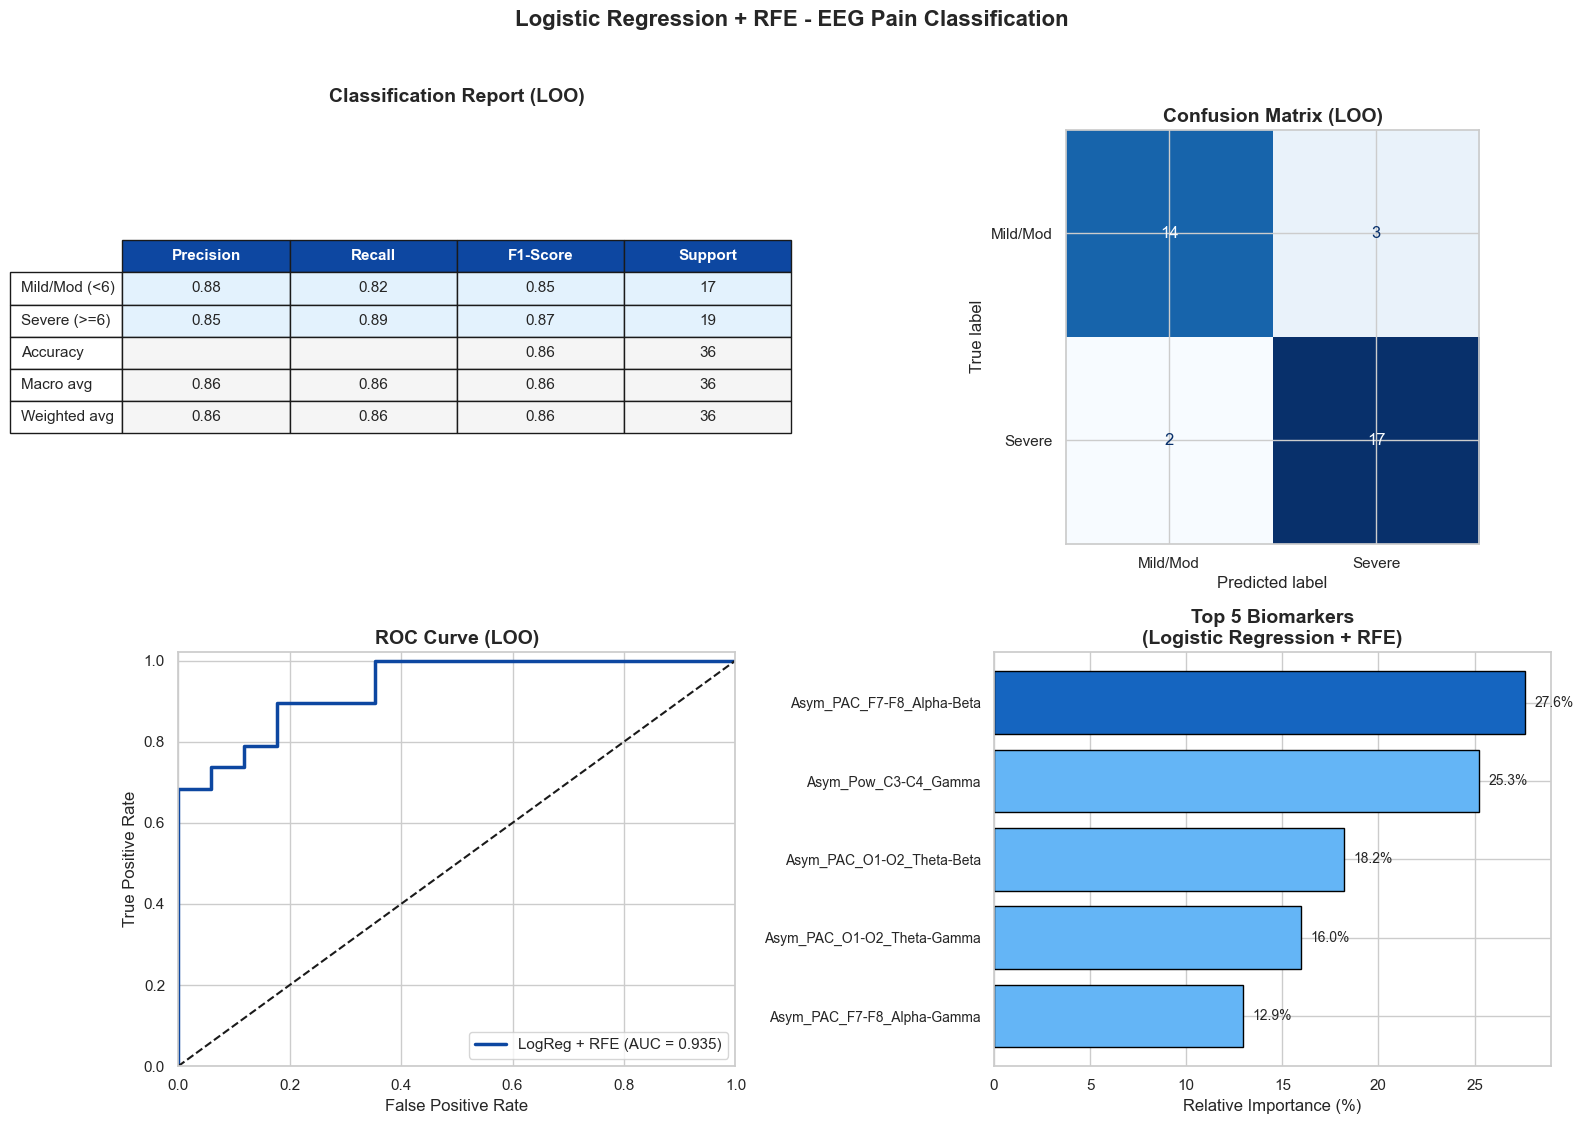


Figure saved as images\logreg_rfe_full_results.png


In [95]:
if X.shape[0] > 0:
    print('=' * 60)
    print("Evaluating Logistic Regression + RFE — class_weight='balanced', LOO + RandomizedSearchCV")
    print('=' * 60)

    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    num_k = 5

    logreg_rfe = LogisticRegression(
        penalty='l1', solver='liblinear', random_state=42,
        class_weight='balanced'  # Corrects class imbalance
    )
    selector_rfe = RFE(estimator=logreg_rfe, n_features_to_select=num_k, step=2)

    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('rfe', selector_rfe),
        ('logreg_final', LogisticRegression(
            penalty='l1', solver='liblinear', random_state=42,
            class_weight='balanced'
        ))
    ])

    param_dist = {
        'logreg_final__C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=10, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    print("Running LOO Nested CV with Logistic Regression + RFE")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    y_proba = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='predict_proba')[:, 1]
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)
    auc_loo = roc_auc_score(y_class, y_proba)

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV + LOGISTIC REGRESSION)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Generate classification report dict for the table
    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Train on full dataset to reveal biomarkers
    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    
    mask = search.best_estimator_.named_steps['rfe'].get_support()
    biomarkers = feature_names_filt[mask]

    importances = np.abs(search.best_estimator_.named_steps['logreg_final'].coef_[0])
    importances_pct = importances / importances.sum() * 100
    ranking = np.argsort(importances_pct)[::-1]
    
    print('-' * 55)
    print(f"\nTOP {num_k} BIOMARKERS (LOGISTIC REGRESSION + RFE):")
    for i, idx in enumerate(ranking, 1):
        print(f"  {i}. {biomarkers[idx]}: {importances_pct[idx]:.1f}% importance")

    # VISUALIZATIONS (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#0d47a1')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#e3f2fd')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5') 

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba)
    ax_roc.plot(fpr, tpr, color='#0d47a1', lw=2.5,
                label=f'LogReg + RFE (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    bios_ordered  = biomarkers[ranking]
    scores_ordered = importances_pct[ranking]
    
    colors = ['#1565c0' if s == scores_ordered.max() else '#64b5f6' for s in scores_ordered]
    bars = ax_feat.barh(range(len(bios_ordered)), scores_ordered[::-1], color=colors[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ordered)))
    ax_feat.set_yticklabels(bios_ordered[::-1], fontsize=10)
    ax_feat.set_xlabel('Relative Importance (%)', fontsize=12)
    ax_feat.set_title(f'Top {num_k} Biomarkers\n(Logistic Regression + RFE)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, scores_ordered[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle('Logistic Regression + RFE - EEG Pain Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'logreg_rfe_full_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

else:
    print("No patients processed.")

#### Logistic Regression (L1/Lasso)

Evaluating Logistic Regression (L1/Lasso) — class_weight='balanced', LOO + GridSearchCV
Severe Pain  (>=6): 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV

CLASSIFICATION PERFORMANCE (LOO NESTED CV - L1/LASSO)
LOO Accuracy: 80.6%
LOO F1-Score: 0.821
LOO AUC-ROC: 0.824

Best hyperparameters: {'lr__C': 1.0}
-------------------------------------------------------

BIOMARKERS SELECTED BY LASSO (14 features):
  1. Asym_Pow_C3-C4_Gamma: weight = +1.7271
  2. Asym_PAC_F7-F8_Alpha-Beta: weight = +1.4171
  3. Asym_PAC_O1-O2_Theta-Beta: weight = -1.0215
  4. Asym_PAC_O1-O2_Theta-Gamma: weight = -0.9382
  5. Asym_PAC_F7-F8_Alpha-Gamma: weight = -0.6818
  6. Asym_Pow_F3-F4_Beta: weight = -0.5236
  7. Asym_PAC_P3-P4_Theta-Gamma: weight = -0.5009
  8. Asym_Pow_F3-F4_Alpha: weight = -0.1914
  9. Asym_Pow_F7-F8_Theta: weight = +0.1309
  10. Asym_Pow_P3-P4_Theta: weight = -0.0789
  11. Asym_PAC_P3-P4_Alpha-Beta: weight = +0.0613
  12. Asym_Pow_C3-C4_Beta: weight = +0.0523
  13. PAC_Fz_Alpha-Gamma: we

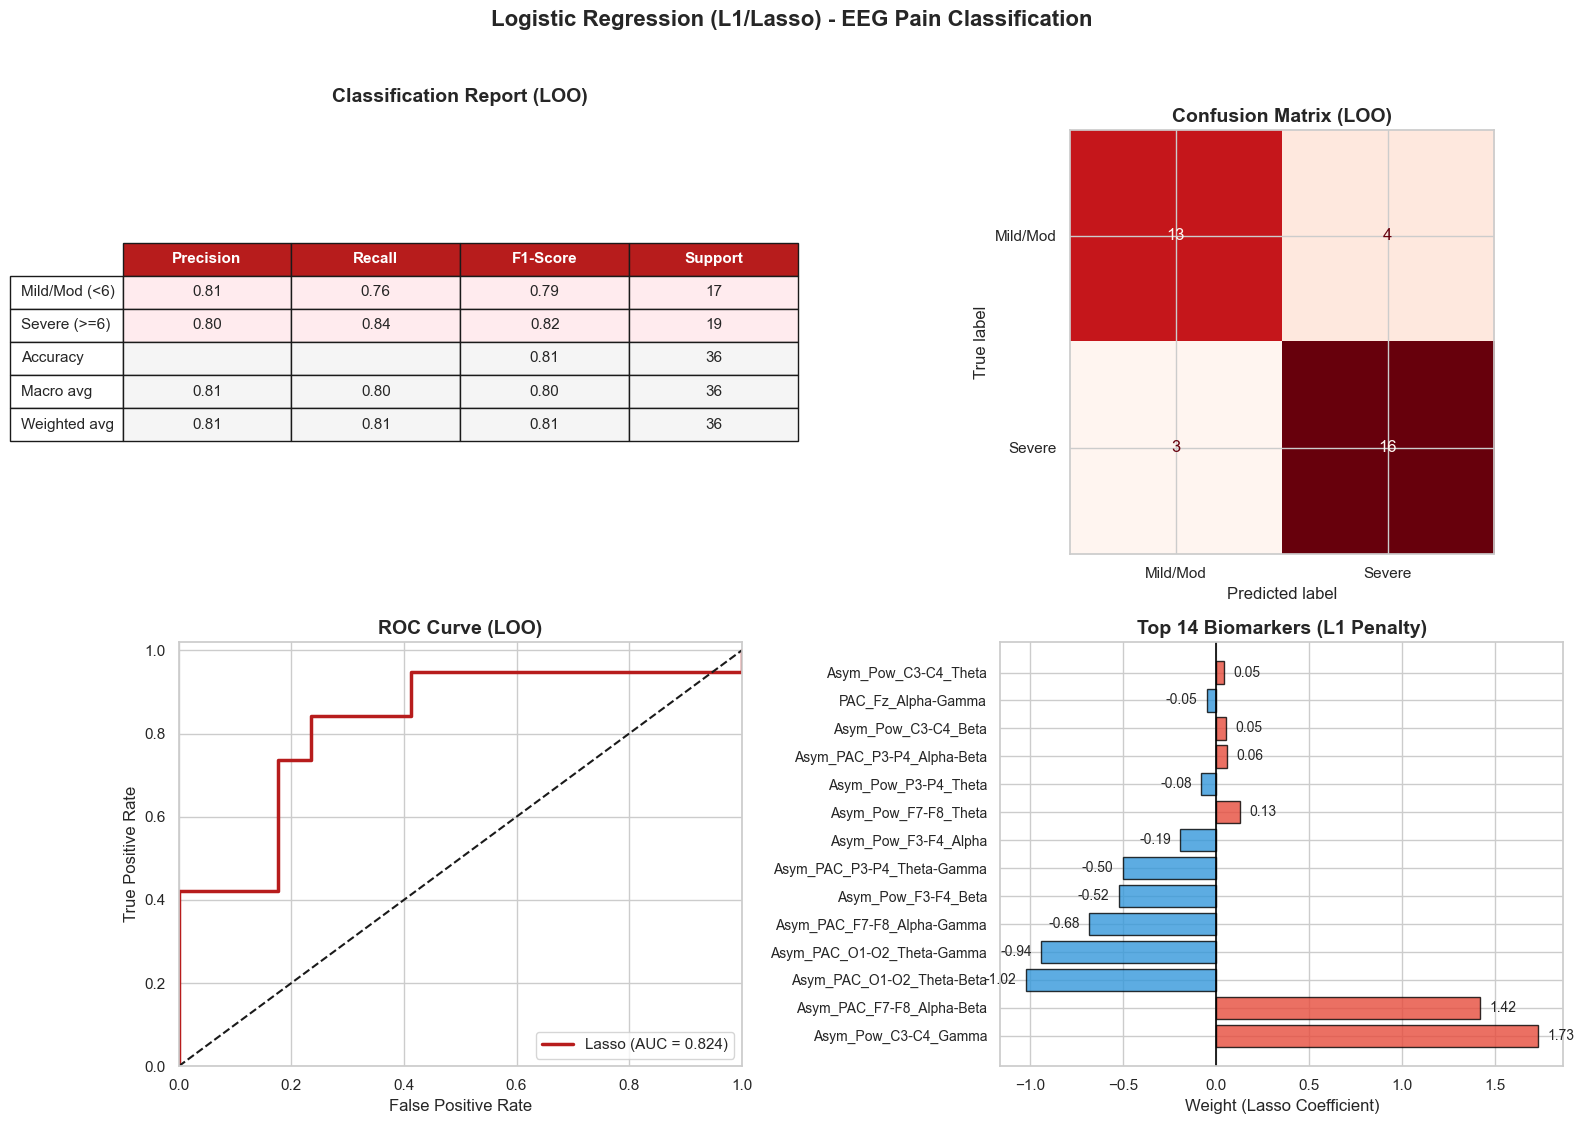


Figure saved as images\lasso_full_results.png


In [96]:
if X.shape[0] > 0:
    print('=' * 60)
    print("Evaluating Logistic Regression (L1/Lasso) — class_weight='balanced', LOO + GridSearchCV")
    print('=' * 60)

    # M1/M2 Filtration
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain  (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    # Base pipeline
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # solver='liblinear' is excellent for small datasets and mandatory for L1 in sklearn
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42))
    ])

    # The C parameter is the inverse of regularization strength.
    # SMALLER values = MORE penalty = FEWER features survive.
    param_grid = {
        'lr__C': [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
    }

    # Reduced to n_splits=3 to ensure larger training blocks in the inner loop
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    outer_cv  = LeaveOneOut()

    # Switched to GridSearchCV since we only have 1 hyperparameter (C) to test
    search = GridSearchCV(
        base_pipeline, param_grid,
        cv=inner_cv, scoring='roc_auc',
        n_jobs=-1, refit=True
    )

    # LOO outer loop
    print("Running LOO Nested CV")
    
    # Run Nested CV to get Accuracy for each fold
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    # Run Nested CV again to get Probabilities (required for ROC-AUC)
    y_proba = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='predict_proba')[:, 1]
    
    # Run Nested CV once more to get predicted classes (0 or 1) for F1-Score
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)

    # Calculate final metrics
    auc_loo = roc_auc_score(y_class, y_proba)
    f1_loo = f1_score(y_class, y_pred)

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV - L1/LASSO)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO F1-Score: {f1_loo:.3f}")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)
    
    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    
    coefficients = search.best_estimator_.named_steps['lr'].coef_[0]
    mask_nonzero = coefficients != 0
    selected_biomarkers = feature_names_filt[mask_nonzero]
    selected_weights = coefficients[mask_nonzero]
    ranking = np.argsort(np.abs(selected_weights))[::-1]

    print('-' * 55)
    print(f"\nBIOMARKERS SELECTED BY LASSO ({len(selected_biomarkers)} features):")
    if len(ranking) == 0:
        print("The model zeroed out all features (penalty too strong or no strong pattern found).")
    else:
        for i, idx in enumerate(ranking, 1):
            sign = "+" if selected_weights[idx] > 0 else "-"
            print(f"  {i}. {selected_biomarkers[idx]}: weight = {sign}{np.abs(selected_weights[idx]):.4f}")

    # VISUALIZATIONS
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#b71c1c')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#ffebee')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5')

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Reds')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba)
    ax_roc.plot(fpr, tpr, color='#b71c1c', lw=2.5,
                label=f'Lasso (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    if len(ranking) > 0:
        top_n = min(15, len(ranking))
        plot_ranking = ranking[:top_n]
        
        top_features = selected_biomarkers[plot_ranking]
        top_weights = selected_weights[plot_ranking]

        # Red for Positive impact (Severe Pain), Blue for Negative (Mild Pain)
        colors = ['#e74c3c' if w > 0 else '#3498db' for w in top_weights]

        y_pos = np.arange(len(top_features))
        bars = ax_feat.barh(y_pos[::-1], top_weights[::-1], color=colors[::-1], edgecolor='black', alpha=0.8)

        ax_feat.set_yticks(y_pos[::-1])
        ax_feat.set_yticklabels(top_features[::-1], fontsize=10)
        ax_feat.set_xlabel('Weight (Lasso Coefficient)', fontsize=12)
        ax_feat.set_title(f'Top {top_n} Biomarkers (L1 Penalty)', fontsize=14, fontweight='bold')
        ax_feat.axvline(0, color='black', linewidth=1.2, linestyle='-')
        
        # Add values next to bars
        for bar, val in zip(bars, top_weights[::-1]):
            offset = 0.05 if val > 0 else -0.05
            ha = 'left' if val > 0 else 'right'
            ax_feat.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                         f'{val:.2f}', va='center', ha=ha, fontsize=10)
    else:
        ax_feat.text(0.5, 0.5, 'All features zeroed out by L1 penalty', 
                     ha='center', va='center', fontsize=12)
        ax_feat.axis('off')

    plt.suptitle('Logistic Regression (L1/Lasso) - EEG Pain Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'lasso_full_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

else:
    print("No patients processed.")


In [102]:
if X.shape[0] > 0:
    print('=' * 60)
    print("Evaluating Logistic Regression (L1/Lasso) — class_weight='balanced', LOO + GridSearchCV")
    print('=' * 60)

    # M1/M2 Filtration
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    # Base pipeline
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # solver='liblinear' is excellent for small datasets and mandatory for L1 in sklearn
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42))
    ])

    # The C parameter is the inverse of regularization strength
    param_grid = {
        'lr__C': [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
    }

    # Reduced to n_splits=3 to ensure larger training blocks in the inner loop
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = GridSearchCV(
        base_pipeline, param_grid,
        cv=inner_cv, scoring='roc_auc',
        n_jobs=-1, refit=True
    )

    # LOO outer loop
    print("Running LOO Nested CV")
    
    # Run Nested CV to get Accuracy for each fold
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    
    # Run Nested CV again to get Probabilities (required for ROC-AUC)
    y_proba = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='predict_proba')[:, 1]
    
    # Run Nested CV once more to get predicted classes (0 or 1) for F1-Score
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)

    # Calculate final metrics
    acc_loo = scores_acc.mean()
    auc_loo = roc_auc_score(y_class, y_proba)
    f1_loo = f1_score(y_class, y_pred)

    print("Calculating 95% Confidence Interval (Bootstrapping)")
    n_bootstraps = 1000
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    
    for i in range(n_bootstraps):
        # Resample with replacement the indices of predictions and ground truth labels
        indices = rng.randint(0, len(y_pred), len(y_pred))
        
        # Ensure the sample contains both classes (prevents mathematical errors in small samples)
        if len(np.unique(y_class[indices])) < 2:
            continue
            
        score = accuracy_score(y_class[indices], y_pred[indices])
        bootstrapped_scores.append(score)
        
    # Extract the 2.5th and 97.5th percentiles for the 95% CI
    lower_bound = np.percentile(bootstrapped_scores, 2.5)
    upper_bound = np.percentile(bootstrapped_scores, 97.5)

    # DISPLAY RESULTS
    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV - L1/LASSO)")
    print(f"LOO Accuracy: {acc_loo*100:.1f}%")
    print(f"95% CI (Acc): [{lower_bound*100:.1f}% , {upper_bound*100:.1f}%]")
    print(f"LOO F1-Score: {f1_loo:.3f}")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    # Train on full dataset to reveal biomarkers
    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    
    # Extract linear model coefficients
    coefficients = search.best_estimator_.named_steps['lr'].coef_[0]
    
    # Lasso magic: we keep only those that were not zeroed out
    mask_nonzero = coefficients != 0
    selected_biomarkers = feature_names_filt[mask_nonzero]
    selected_weights = coefficients[mask_nonzero]
    
    # Sorting by absolute impact (whether positive or negative)
    ranking = np.argsort(np.abs(selected_weights))[::-1]

    print('-' * 55)
    print(f"\nBIOMARKERS SELECTED BY LASSO ({len(selected_biomarkers)} features):")
    if len(ranking) == 0:
        print("The model zeroed out all features (penalty too strong and no strong pattern found)")
    else:
        for i, idx in enumerate(ranking, 1):
            sign = "+" if selected_weights[idx] > 0 else "-"
            print(f"  {i}. {selected_biomarkers[idx]}: weight = {sign}{np.abs(selected_weights[idx]):.4f}")
else:
    print("No patients processed")

Evaluating Logistic Regression (L1/Lasso) — class_weight='balanced', LOO + GridSearchCV
Severe Pain (>=6): 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV
Calculating 95% Confidence Interval (Bootstrapping)

CLASSIFICATION PERFORMANCE (LOO NESTED CV - L1/LASSO)
LOO Accuracy: 80.6%
95% CI (Acc): [66.7% , 91.7%]
LOO F1-Score: 0.821
LOO AUC-ROC: 0.824

Best hyperparameters: {'lr__C': 1.0}
-------------------------------------------------------

BIOMARKERS SELECTED BY LASSO (14 features):
  1. Asym_Pow_C3-C4_Gamma: weight = +1.7271
  2. Asym_PAC_F7-F8_Alpha-Beta: weight = +1.4171
  3. Asym_PAC_O1-O2_Theta-Beta: weight = -1.0215
  4. Asym_PAC_O1-O2_Theta-Gamma: weight = -0.9382
  5. Asym_PAC_F7-F8_Alpha-Gamma: weight = -0.6818
  6. Asym_Pow_F3-F4_Beta: weight = -0.5236
  7. Asym_PAC_P3-P4_Theta-Gamma: weight = -0.5009
  8. Asym_Pow_F3-F4_Alpha: weight = -0.1914
  9. Asym_Pow_F7-F8_Theta: weight = +0.1309
  10. Asym_Pow_P3-P4_Theta: weight = -0.0789
  11. Asym_PAC_P3-P4_Alpha-Beta: weight =

Preparing Permutation Test (1000 rounds)

PERMUTATION TEST RESULTS
Actual Model Accuracy: 80.6%
Average Random Accuracy: 49.2%
p-value: 0.0060

[SUCCESS] The result is statistically significant (p < 0.05). The pain signature is real


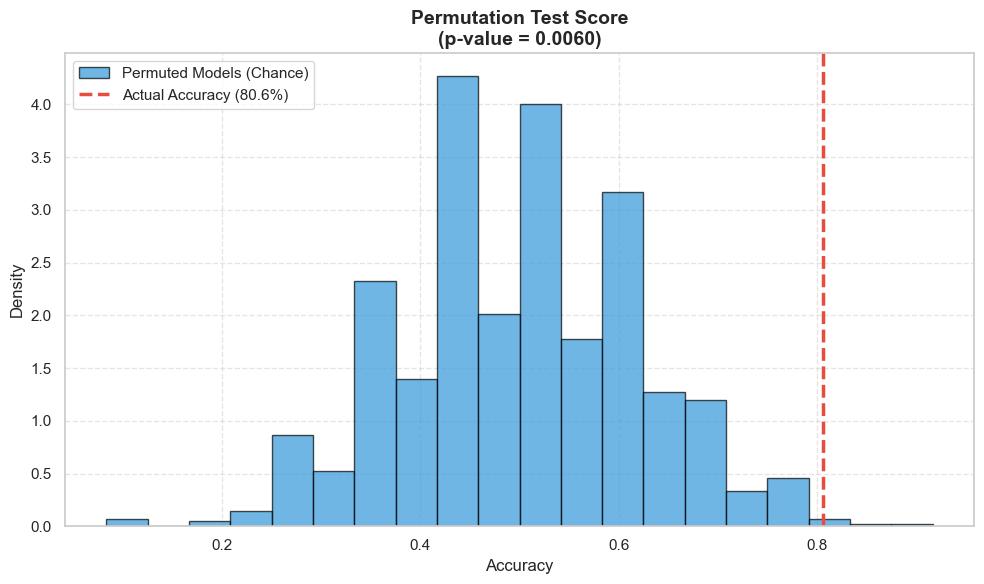


Figure saved as images\permutation_test_histogram.png


In [78]:
# Ensure that X_filtered and y_class are already loaded
if X.shape[0] > 0:
    print("Preparing Permutation Test (1000 rounds)")

    # We build the pipeline with the best hyperparameter already found (C=1.0)
    optimized_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', C=1.0, class_weight='balanced', random_state=42))
    ])

    outer_cv = LeaveOneOut()
    
    # The magic Scikit-Learn function that does all the heavy lifting
    # n_jobs=-1 uses all your processor cores to speed it up
    actual_score, permuted_scores, p_value = permutation_test_score(
        optimized_pipeline, X_filtered, y_class, cv=outer_cv,
        scoring='accuracy', n_permutations=1000, n_jobs=-1, random_state=42
    )

    print("\nPERMUTATION TEST RESULTS")
    print(f"Actual Model Accuracy: {actual_score * 100:.1f}%")
    print(f"Average Random Accuracy: {permuted_scores.mean() * 100:.1f}%")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("\n[SUCCESS] The result is statistically significant (p < 0.05). The pain signature is real")
    else:
        print("\n[ALERT] The result did not reach significance (p >= 0.05). The model might be overfitting to noise.")

    # Plotting the Academic Proof Histogram
    plt.figure(figsize=(10, 6))
    
    # Plots the distribution of how the model performed when the data was pure noise (guessing)
    plt.hist(permuted_scores, bins=20, density=True, alpha=0.7, color='#3498db', edgecolor='black', label='Permuted Models (Chance)')
    
    # Marks where your true model landed
    plt.axvline(actual_score, color='#e74c3c', linestyle='dashed', linewidth=2.5, label=f'Actual Accuracy ({actual_score*100:.1f}%)')  

    plt.title(f'Permutation Test Score\n(p-value = {p_value:.4f})', fontsize=14, fontweight='bold')
    plt.xlabel('Accuracy', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'permutation_test_histogram.png')
    
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

else:
    print("X_filtered matrix not found")

ElasticNet

Evaluating Logistic Regression (Elastic Net) - class_weight='balanced', LOO + GridSearchCV
Severe Pain (>=6): 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV

CLASSIFICATION PERFORMANCE (LOO NESTED CV - ELASTIC NET)
LOO Accuracy: 63.9%
LOO F1-Score: 0.629
LOO AUC-ROC: 0.647

Best hyperparameters: {'lr__C': 5.0}
-------------------------------------------------------

BIOMARKERS SELECTED BY ELASTIC NET (78 features):
  1. Asym_PAC_F7-F8_Alpha-Beta: weight = +1.5188
  2. Asym_Pow_C3-C4_Gamma: weight = +1.4155
  3. Asym_PAC_O1-O2_Theta-Gamma: weight = -1.2003
  4. Asym_Pow_C3-C4_Beta: weight = +0.8394
  5. Asym_PAC_O1-O2_Theta-Beta: weight = -0.8275
  6. Asym_PAC_P3-P4_Alpha-Beta: weight = +0.8031
  7. Asym_Pow_F3-F4_Beta: weight = -0.7732
  8. Asym_Pow_F3-F4_Alpha: weight = -0.7070
  9. Asym_PAC_F7-F8_Alpha-Gamma: weight = -0.6624
  10. Pow_C4_Alpha: weight = +0.6472
  11. Asym_Pow_P3-P4_Theta: weight = -0.6420
  12. Pow_C3_Alpha: weight = +0.5837
  13. Asym_Pow_F7-F8_Alpha: weight = +0

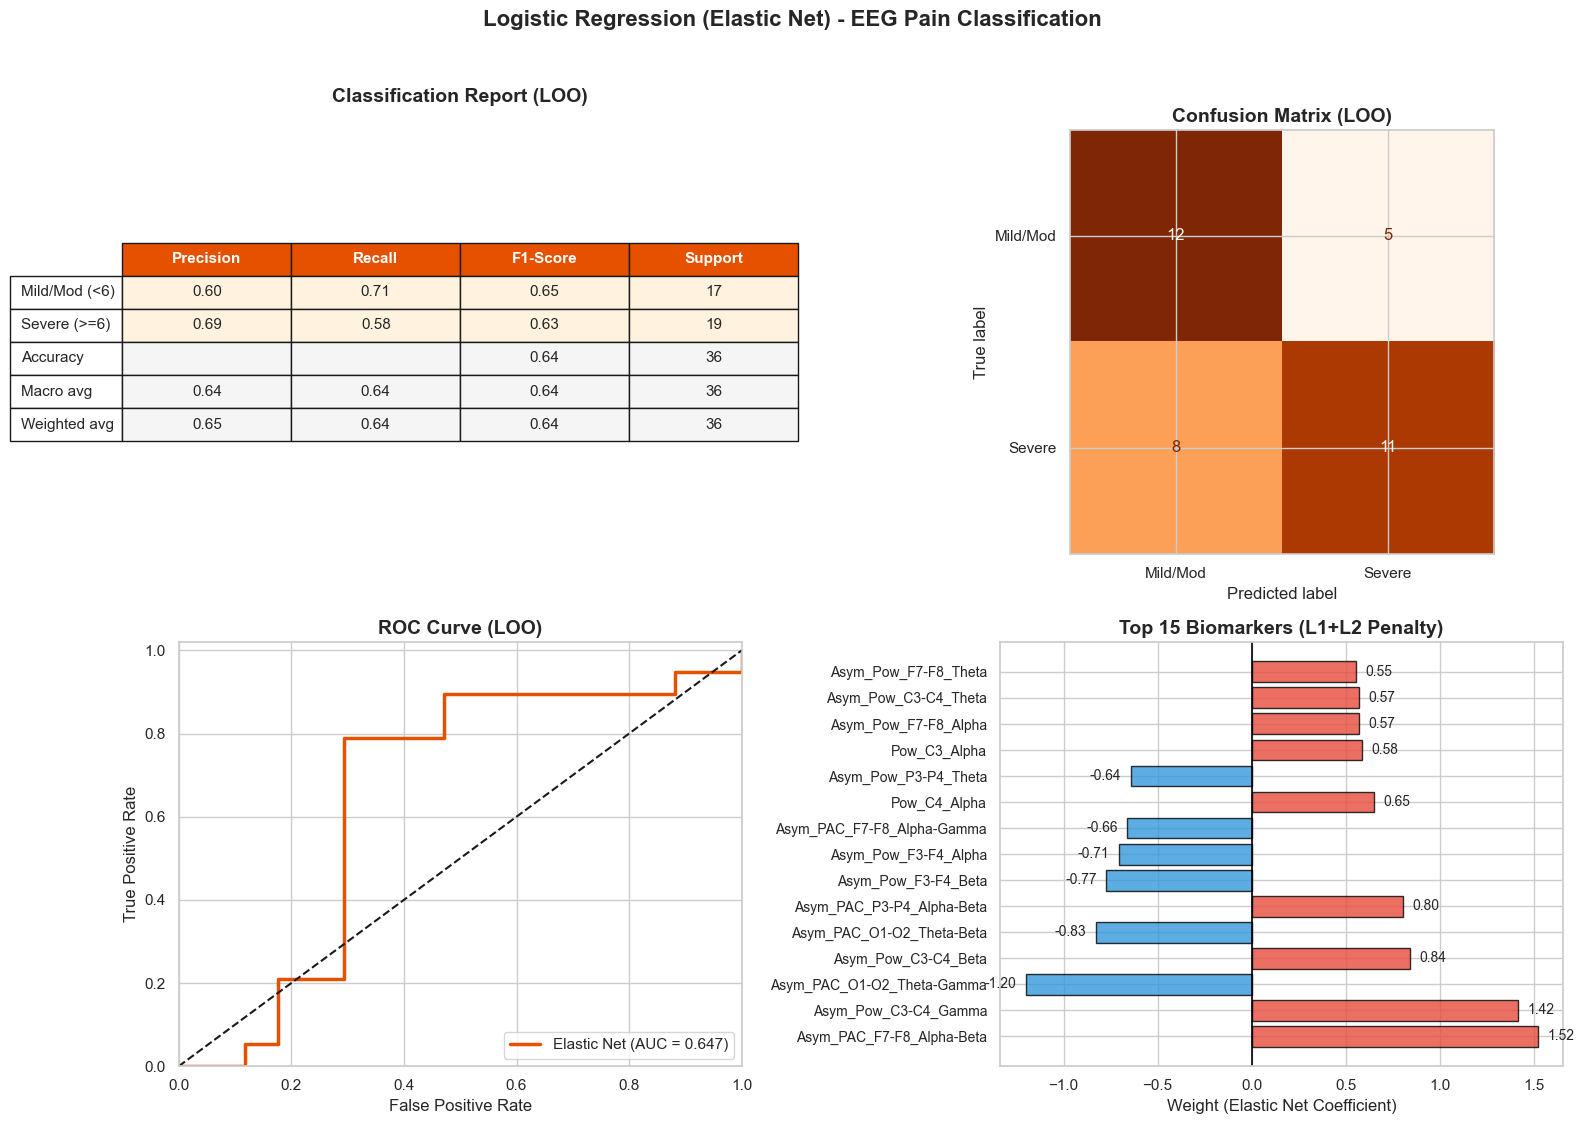


Figure saved as images\elasticnet_full_results.png


In [98]:
if X.shape[0] > 0:
    print('=' * 60)
    print("Evaluating Logistic Regression (Elastic Net) - class_weight='balanced', LOO + GridSearchCV")
    print('=' * 60)

    # M1/M2 Filtering
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filtered = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f"Severe Pain (>=6): {sum(y_class==1)}")
    print(f"Mild/Mod Pain (<6): {sum(y_class==0)}\n")

    # Base pipeline
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            penalty='elasticnet', 
            solver='saga', 
            l1_ratio=0.5, # Fixes exactly 50% L1 and 50% L2
            class_weight='balanced', 
            random_state=42, 
            max_iter=10000
        ))
    ])

    # Hyperparameter Grid
    param_grid = {
        # C:Inverse of overall regularization strength
        'lr__C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
    }

    # Reduced to n_splits=3 to have larger training blocks in the inner loop
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = GridSearchCV(
        base_pipeline, param_grid,
        cv=inner_cv, scoring='roc_auc',
        n_jobs=-1, refit=True
    )

    # LOO outer loop
    print("Running LOO Nested CV")
    scores_acc = cross_val_score(search, X_filtered, y_class, cv=outer_cv, scoring='accuracy')
    y_proba = cross_val_predict(search, X_filtered, y_class, cv=outer_cv, method='predict_proba')[:, 1]
    y_pred = cross_val_predict(search, X_filtered, y_class, cv=outer_cv)

    # Calculates final metrics
    auc_loo = roc_auc_score(y_class, y_proba)
    f1_loo = f1_score(y_class, y_pred)

    print("\nCLASSIFICATION PERFORMANCE (LOO NESTED CV - ELASTIC NET)")
    print(f"LOO Accuracy: {scores_acc.mean()*100:.1f}%")
    print(f"LOO F1-Score: {f1_loo:.3f}")
    print(f"LOO AUC-ROC: {auc_loo:.3f}")

    report = classification_report(y_class, y_pred,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    search.fit(X_filtered, y_class)
    print(f"\nBest hyperparameters: {search.best_params_}")
    
    # Extracting the linear model coefficients
    coefficients = search.best_estimator_.named_steps['lr'].coef_[0]
    
    # The magic of Elastic Net: we keep what wasn't zeroed out
    mask_nonzero = coefficients != 0
    selected_biomarkers = feature_names_filt[mask_nonzero]
    selected_weights = coefficients[mask_nonzero]
    ranking = np.argsort(np.abs(selected_weights))[::-1]

    print('-' * 55)
    print(f"\nBIOMARKERS SELECTED BY ELASTIC NET ({len(selected_biomarkers)} features):")
    if len(ranking) == 0:
        print("The model zeroed out all features (penalty too strong)")
    else:
        for i, idx in enumerate(ranking, 1):
            signal = "+" if selected_weights[idx] > 0 else "-"
            print(f"  {i}. {selected_biomarkers[idx]}: weight = {signal}{np.abs(selected_weights[idx]):.4f}")

    # VISUALIZATIONS
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#e65100')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#fff3e0')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5')

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Oranges')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba)
    ax_roc.plot(fpr, tpr, color='#e65100', lw=2.5,
                label=f'Elastic Net (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Top Features
    if len(ranking) > 0:
        # Cap to top 15 for visualization clarity
        top_n = min(15, len(ranking))
        plot_ranking = ranking[:top_n]
        
        top_features = selected_biomarkers[plot_ranking]
        top_weights = selected_weights[plot_ranking]

        # Red for Positive impact (Severe Pain), Blue for Negative (Mild Pain)
        colors = ['#e74c3c' if w > 0 else '#3498db' for w in top_weights]

        y_pos = np.arange(len(top_features))
        bars = ax_feat.barh(y_pos[::-1], top_weights[::-1], color=colors[::-1], edgecolor='black', alpha=0.8)

        ax_feat.set_yticks(y_pos[::-1])
        ax_feat.set_yticklabels(top_features[::-1], fontsize=10)
        ax_feat.set_xlabel('Weight (Elastic Net Coefficient)', fontsize=12)
        ax_feat.set_title(f'Top {top_n} Biomarkers (L1+L2 Penalty)', fontsize=14, fontweight='bold')
        ax_feat.axvline(0, color='black', linewidth=1.2, linestyle='-')
        
        for bar, val in zip(bars, top_weights[::-1]):
            offset = 0.05 if val > 0 else -0.05
            ha = 'left' if val > 0 else 'right'
            ax_feat.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                         f'{val:.2f}', va='center', ha=ha, fontsize=10)
    else:
        ax_feat.text(0.5, 0.5, 'All features zeroed out by penalty', 
                     ha='center', va='center', fontsize=12)
        ax_feat.axis('off')

    plt.suptitle('Logistic Regression (Elastic Net) - EEG Pain Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'elasticnet_full_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nFigure saved as {save_path}")

else:
    print("No patients processed")

#### LDA com Shrinkage (Ledoit-Wolf)

  LDA com Shrinkage de Ledoit-Wolf
  LOO Nested CV + mutual_info_classif

Severe Pain  (>=6) : 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV (LDA Shrinkage)

RESULTS (LDA + SHRINKAGE + LOO)
LOO Accuracy : 36.1%
LOO AUC-ROC : 0.272

Best hyperparameters: {'selector__k': 15, 'lda__tol': 0.0001}
-------------------------------------------------------

DISCRIMINANT FUNCTION - TOP 15 FEATURES:
Feature                                 Coef   |Coef|%
  Asym_Pow_P3-P4_Alpha              - 0.4453     13.7%
  PAC_Fz_Alpha-Gamma                - 0.3964     12.2%
  Asym_Pow_P3-P4_Theta              - 0.3879     11.9%
  PAC_F4_Alpha-Gamma                - 0.3172      9.7%
  Asym_Pow_F7-F8_Beta               + 0.2805      8.6%
  Asym_PAC_P3-P4_Alpha-Beta         + 0.2362      7.2%
  Asym_PAC_F7-F8_Theta-Gamma        + 0.2241      6.9%
  Asym_PAC_P3-P4_Theta-Beta         - 0.2140      6.6%
  PAC_P3_Theta-Beta                 + 0.1948      6.0%
  PAC_P3_Alpha-Beta                 + 0.1927      5.9%


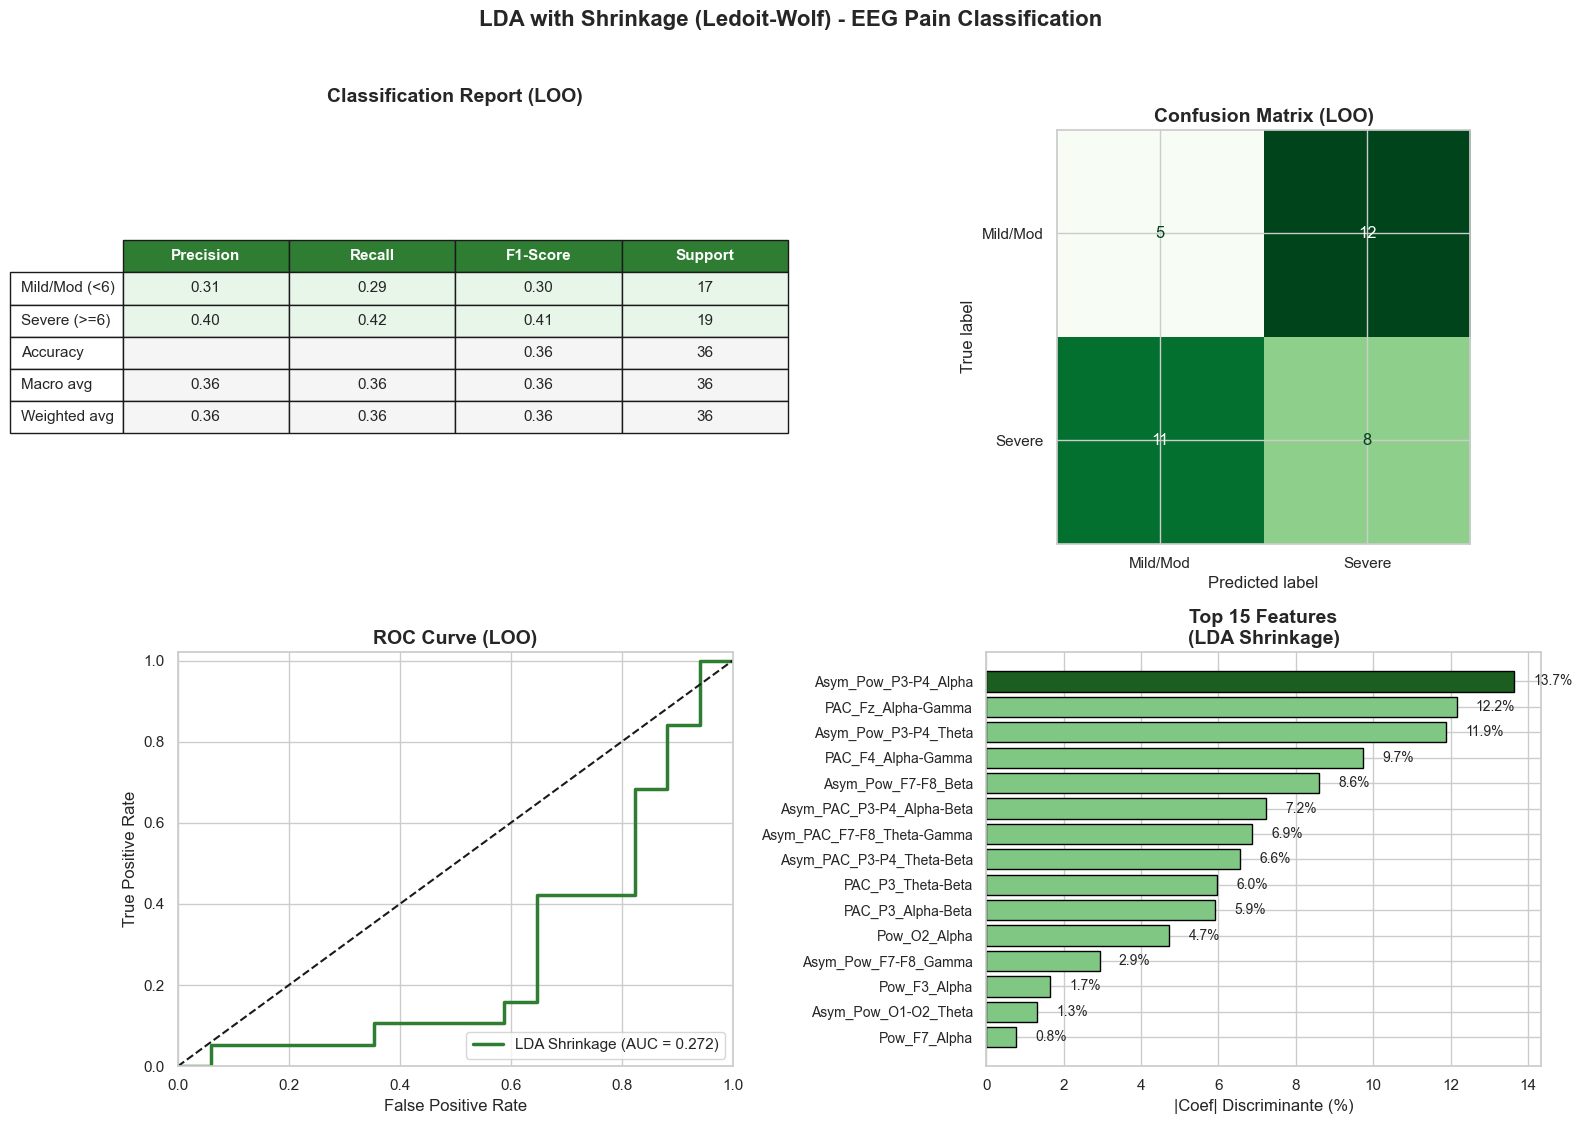


Figure saved as images\lda_shrinkage_full_results.png


In [99]:
if X.shape[0] > 0:
    print('=' * 60)
    print('  LDA com Shrinkage de Ledoit-Wolf')
    print('  LOO Nested CV + mutual_info_classif')
    print('=' * 60)

    # Filter M1/M2
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filt = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f'\nSevere Pain  (>=6) : {sum(y_class == 1)}')
    print(f'Mild/Mod Pain (<6): {sum(y_class == 0)}\n')

    # Pipeline
    # shrinkage='auto': Ledoit-Wolf, ideal for n_samples ~= n_features
    # solver='eigen' is mandatory for custom shrinkage
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif)),
        ('lda', LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto'))
    ])

    param_dist = {
        'selector__k': [3, 5, 7, 10, 15],
        'lda__tol': [1e-4, 1e-3, 1e-2],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv  = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=15, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    # LOO Nested CV
    print('Running LOO Nested CV (LDA Shrinkage)')
    scores_acc = cross_val_score(search, X_filt, y_class, cv=outer_cv, scoring='accuracy')
    y_pred_loo = cross_val_predict(search, X_filt, y_class, cv=outer_cv)
    y_proba_loo = cross_val_predict(search, X_filt, y_class,
                                    cv=outer_cv, method='predict_proba')[:, 1]
    auc_loo = roc_auc_score(y_class, y_proba_loo)

    print('\nRESULTS (LDA + SHRINKAGE + LOO)')
    print(f'LOO Accuracy : {scores_acc.mean()*100:.1f}%')
    print(f'LOO AUC-ROC : {auc_loo:.3f}')
    
    # Generate classification report dict for the table
    report = classification_report(y_class, y_pred_loo,
                                   target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                   output_dict=True, zero_division=0)

    # Train on full dataset for biomarkers
    search.fit(X_filt, y_class)
    best_k = search.best_params_.get('selector__k', 5)
    print(f'\nBest hyperparameters: {search.best_params_}')

    lda_step = search.best_estimator_.named_steps['lda']
    selector_step = search.best_estimator_.named_steps['selector']
    mask = selector_step.get_support()
    biomarkers = feature_names_filt[mask]

    # coef_ shape (1, k) for binary classification
    coefs = lda_step.coef_[0]
    coefs_abs = np.abs(coefs)
    coefs_pct = coefs_abs / coefs_abs.sum() * 100
    ranking = np.argsort(coefs_pct)[::-1]

    print('-' * 55)
    print(f'\nDISCRIMINANT FUNCTION - TOP {best_k} FEATURES:')
    print(f'{"Feature":<35} {"Coef":>8}  {"|Coef|%":>8}')
    for i in ranking:
        sign = '+' if coefs[i] > 0 else '-'
        print(f'  {biomarkers[i]:<33} {sign}{abs(coefs[i]):>7.4f}  {coefs_pct[i]:>7.1f}%')

    # VISUALIZATIONS
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    # Flatten axes for easier assignment
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report['macro avg']['support'])
            table_data.append(['', '', f"{report['accuracy']:.2f}", str(n_total)])
        else:
            r = report[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#2e7d32')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#e8f5e9')
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5')

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred_loo)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Greens')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba_loo)
    ax_roc.plot(fpr, tpr, color='#2e7d32', lw=2.5,
                label=f'LDA Shrinkage (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Discriminant Function Coefficients
    bios_ord = biomarkers[ranking]
    coefs_ord = coefs_pct[ranking]
    
    colors_lda = ['#1b5e20' if c == coefs_ord.max() else '#81c784' for c in coefs_ord]
    bars = ax_feat.barh(range(len(bios_ord)), coefs_ord[::-1], color=colors_lda[::-1], edgecolor='black')
    
    ax_feat.set_yticks(range(len(bios_ord)))
    ax_feat.set_yticklabels(bios_ord[::-1], fontsize=10)
    ax_feat.set_xlabel('|Coef| Discriminante (%)', fontsize=12)
    ax_feat.set_title(f'Top {best_k} Features\n(LDA Shrinkage)', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, coefs_ord[::-1]):
        ax_feat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.suptitle('LDA with Shrinkage (Ledoit-Wolf) - EEG Pain Classification',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'lda_shrinkage_full_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\nFigure saved as {save_path}')

else:
    print('No patients processed.')

#### PLS-DA (Partial Least Squares Discriminant Analysis)

  PLS-DA (Partial Least Squares Discriminant Analysis)
  LOO Nested CV + mutual_info_classif

Severe Pain  (>=6) : 19
Mild/Mod Pain (<6): 17

Running LOO Nested CV (PLS-DA)

- RESULTS (PLS-DA + LOO) -
LOO Accuracy : 25.0%
LOO AUC-ROC : 0.190

Best hyperparameters: {'selector__k': 5, 'plsda__n_components': 1}
-------------------------------------------------------

VIP SCORES -- TOP 5 FEATURES:
Feature                                VIP  Relevante
  Asym_Pow_P3-P4_Alpha               1.561  sim (>1.0)
  PAC_Fz_Alpha-Gamma                 1.183  sim (>1.0)
  PAC_P3_Alpha-Beta                  0.986  ---
  Asym_Pow_F7-F8_Gamma               0.395  ---
  Pow_F3_Alpha                       0.192  ---


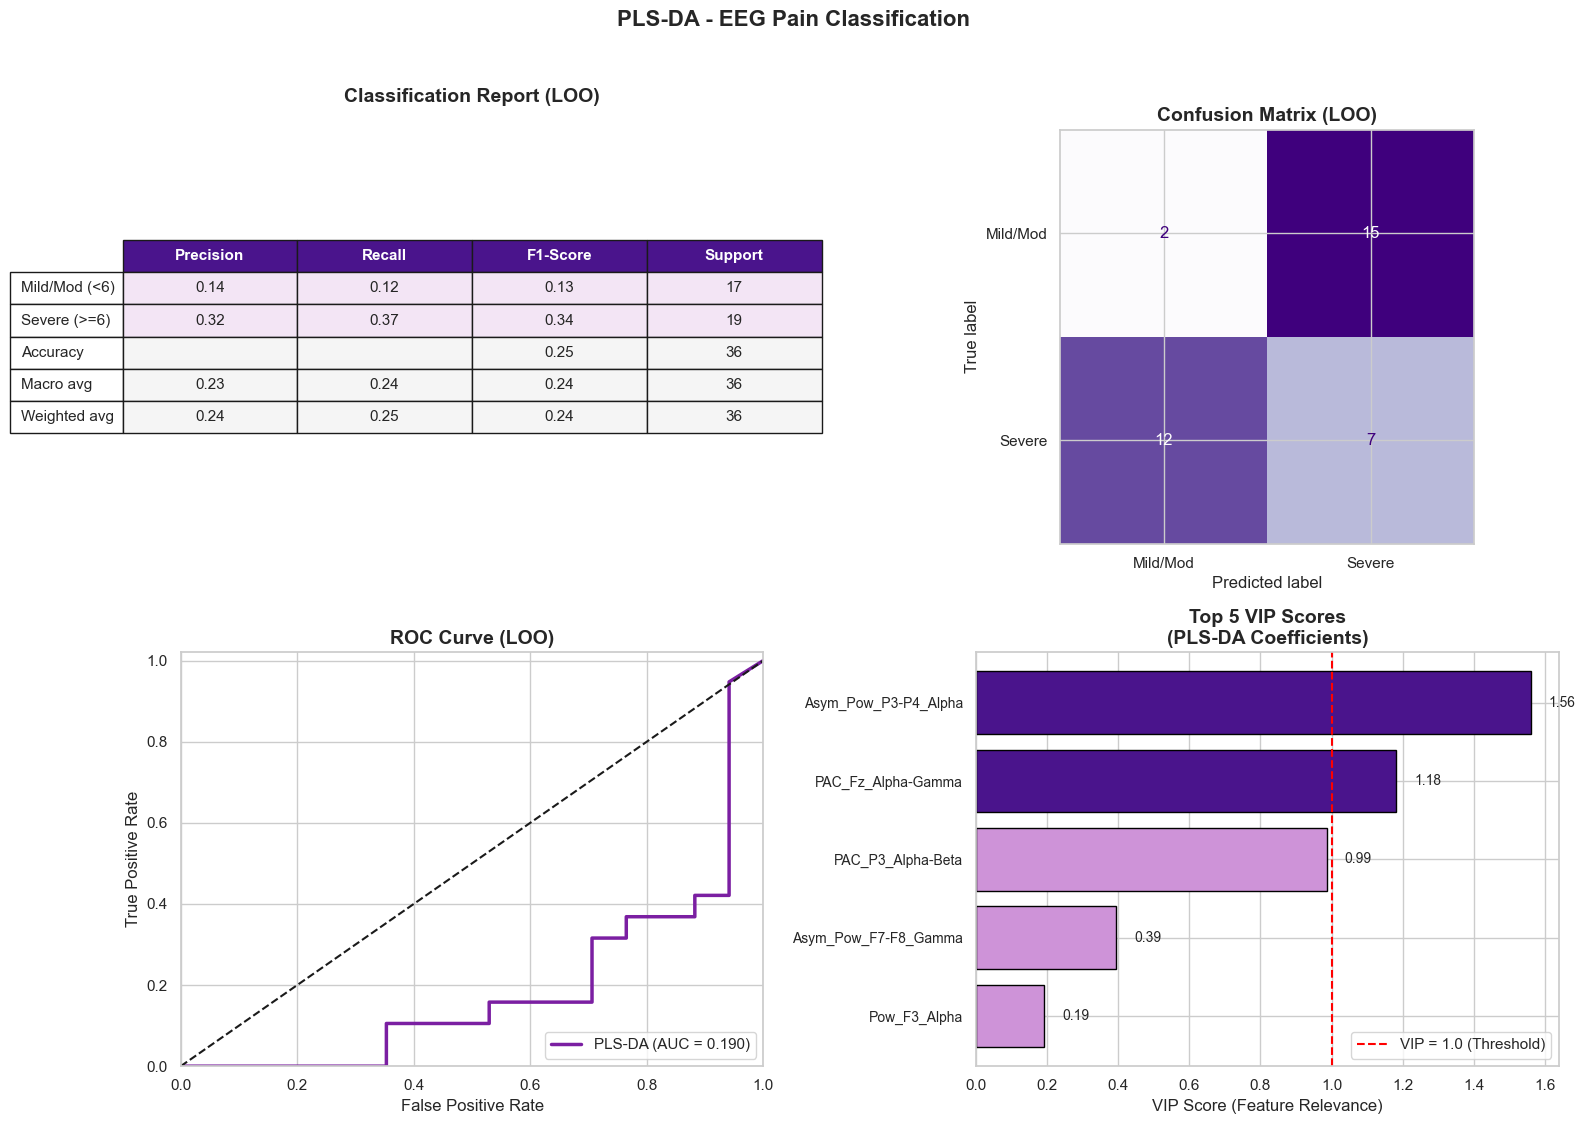


Figure saved as images\plsda_2x2_results.png


In [100]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Wrapper PLS-DA
class PLSDAClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2, scale=True):
        self.n_components = n_components
        self.scale = scale

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.pls_ = PLSRegression(n_components=self.n_components, scale=self.scale)
        self.pls_.fit(X, y.astype(float))
        return self

    def predict(self, X):
        raw = self.pls_.predict(X).ravel()
        return (raw >= 0.5).astype(int)

    def predict_proba(self, X):
        raw = self.pls_.predict(X).ravel()
        prob = np.clip(raw, 0, 1)
        return np.column_stack([1 - prob, prob])

    def transform(self, X):
        return self.pls_.transform(X)

if X.shape[0] > 0:
    print('=' * 60)
    print('  PLS-DA (Partial Least Squares Discriminant Analysis)')
    print('  LOO Nested CV + mutual_info_classif')
    print('=' * 60)

    # Filter M1/M2
    valid_mask = [not ('M1' in n or 'M2' in n) for n in feature_names]
    X_filt = X[:, valid_mask]
    feature_names_filt = np.array(feature_names)[valid_mask]

    y_class = np.where(y >= 6, 1, 0)
    print(f'\nSevere Pain  (>=6) : {sum(y_class == 1)}')
    print(f'Mild/Mod Pain (<6): {sum(y_class == 0)}\n')

    # Pipeline
    base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif)),
        ('plsda', PLSDAClassifier())
    ])

    param_dist = {
        'plsda__n_components': [1, 2, 3, 4],
        'selector__k': [5, 7, 10, 15, 20],
    }

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = LeaveOneOut()

    search = RandomizedSearchCV(
        base_pipeline, param_dist,
        n_iter=15, cv=inner_cv, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )

    # LOO Nested CV
    print('Running LOO Nested CV (PLS-DA)')
    scores_acc = cross_val_score(search, X_filt, y_class, cv=outer_cv, scoring='accuracy')
    y_pred_loo = cross_val_predict(search, X_filt, y_class, cv=outer_cv)
    y_proba_loo = cross_val_predict(search, X_filt, y_class,
                                    cv=outer_cv, method='predict_proba')[:, 1]
    auc_loo = roc_auc_score(y_class, y_proba_loo)

    print('\n- RESULTS (PLS-DA + LOO) -')
    print(f'LOO Accuracy : {scores_acc.mean()*100:.1f}%')
    print(f'LOO AUC-ROC : {auc_loo:.3f}')
    
    report_dict = classification_report(y_class, y_pred_loo,
                                        target_names=['Mild/Mod (<6)', 'Severe (>=6)'],
                                        output_dict=True, zero_division=0)

    # Train on full dataset
    search.fit(X_filt, y_class)
    best_k = search.best_params_.get('selector__k', 10)
    print(f'\nBest hyperparameters: {search.best_params_}')

    plsda_step = search.best_estimator_.named_steps['plsda']
    selector_step = search.best_estimator_.named_steps['selector']
    mask = selector_step.get_support()
    biomarkers = feature_names_filt[mask]

    # VIP scores
    W = plsda_step.pls_.x_weights_
    T = plsda_step.pls_.x_scores_
    Q = plsda_step.pls_.y_loadings_
    p = W.shape[0]
    SS = (T ** 2 * Q ** 2).sum(axis=0)
    SS_total = SS.sum()
    W_norm = W / np.linalg.norm(W, axis=0, keepdims=True)
    VIP = np.sqrt(p * (W_norm ** 2 @ SS) / SS_total)

    ranking_vip = np.argsort(VIP)[::-1]
    print('-' * 55)
    print(f'\nVIP SCORES -- TOP {best_k} FEATURES:')
    print(f'{"Feature":<35} {"VIP":>6}  {"Relevante":>9}')
    for i in ranking_vip:
        relevant = 'sim (>1.0)' if VIP[i] >= 1.0 else '---'
        print(f'  {biomarkers[i]:<33} {VIP[i]:>6.3f}  {relevant}')

    # VISUALIZATIONS 
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    ax_tbl, ax_cm = axes[0, 0], axes[0, 1]
    ax_roc, ax_feat = axes[1, 0], axes[1, 1]

    # Classification Report Table
    row_labels = ['Mild/Mod (<6)', 'Severe (>=6)', 'Accuracy', 'Macro avg', 'Weighted avg']
    col_labels = ['Precision', 'Recall', 'F1-Score', 'Support']
    keys = ['Mild/Mod (<6)', 'Severe (>=6)', 'accuracy', 'macro avg', 'weighted avg']

    table_data = []
    for k in keys:
        if k == 'accuracy':
            n_total = int(report_dict['macro avg']['support'])
            table_data.append(['', '', f"{report_dict['accuracy']:.2f}", str(n_total)])
        else:
            r = report_dict[k]
            table_data.append([
                f"{r['precision']:.2f}" if 'precision' in r else '',
                f"{r['recall']:.2f}" if 'recall' in r else '',
                f"{r['f1-score']:.2f}",
                str(int(r['support']))
            ])

    ax_tbl.axis('off')
    tbl = ax_tbl.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.8)

    # Styling Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#4a148c') 
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, 3):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f3e5f5') 
    for i in range(3, 6):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor('#f5f5f5')

    ax_tbl.set_title('Classification Report (LOO)', fontsize=14, fontweight='bold', pad=20)

    # Confusion Matrix
    cm = confusion_matrix(y_class, y_pred_loo)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Mild/Mod', 'Severe'])
    disp.plot(ax=ax_cm, colorbar=False, cmap='Purples')
    ax_cm.set_title('Confusion Matrix (LOO)', fontsize=14, fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_class, y_proba_loo)
    ax_roc.plot(fpr, tpr, color='#7b1fa2', lw=2.5, label=f'PLS-DA (AUC = {auc_loo:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set(xlim=[0, 1], ylim=[0, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title('ROC Curve (LOO)', fontsize=14, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)

    # Discriminant Coefficients (VIP Scores)
    top_n = min(15, len(biomarkers))
    top_idx = ranking_vip[:top_n]
    top_bios = biomarkers[top_idx]
    top_vips = VIP[top_idx]
    
    colors_vip = ['#4a148c' if v >= 1.0 else '#ce93d8' for v in top_vips]
    bars = ax_feat.barh(range(top_n), top_vips[::-1], color=colors_vip[::-1], edgecolor='black')
    ax_feat.axvline(1.0, color='red', lw=1.5, ls='--', label='VIP = 1.0 (Threshold)')
    
    ax_feat.set_yticks(range(top_n))
    ax_feat.set_yticklabels(top_bios[::-1], fontsize=10)
    ax_feat.set_xlabel('VIP Score (Feature Relevance)', fontsize=12)
    ax_feat.set_title(f'Top {top_n} VIP Scores\n(PLS-DA Coefficients)', fontsize=14, fontweight='bold')
    ax_feat.legend(fontsize=11, loc='lower right')

    for bar, val in zip(bars, top_vips[::-1]):
        ax_feat.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}', va='center', fontsize=10)

    plt.suptitle('PLS-DA - EEG Pain Classification', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    save_folder = 'images'
    os.makedirs(save_folder, exist_ok=True)
    save_path = os.path.join(save_folder, 'plsda_2x2_results.png')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\nFigure saved as {save_path}')

else:
    print('No patients processed')